# Analysis of Tolstoy's and Dostoevsky's vocabularies

Сравнение скорости роста словаря в «Войне и мире» Толстого и «Братьях Карамазовых» Достоевского.
Анализ оригинальных и перемешанных версий. Поиск характерных слов каждого автора.

In [62]:
import requests
import re
import html as html_lib
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## 1. Загрузка текстов с az.lib.ru

In [63]:
def fetch_text_from_azlib(urls):
    """Скачивает HTML-страницы с az.lib.ru и извлекает чистый текст."""
    full_text = []
    for url in urls:
        resp = requests.get(url)
        resp.encoding = resp.apparent_encoding 
        html = resp.text
        # Убираем редакторские блоки (варианты, разночтения, комментарии)
        html = re.split(r'ПЕЧАТНЫЕ ВАРИАНТЫ|ВАРИАНТЫ И РАЗНОЧТЕНИЯ|КОММЕНТАРИИ', html)[0]
        text = re.sub(r"<br[^>]*>", " ", html, flags=re.IGNORECASE)
        text = re.sub(r"<[^>]+>", "", text)
        # Декодируем ВСЕ HTML-entities
        text = html_lib.unescape(text)
        # Убираем лишние пробелы
        text = re.sub(r"\s+", " ", text).strip()
        full_text.append(text)
    return " ".join(full_text)

# Война и мир — 4 тома
tolstoy_urls = [
    "http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0040.shtml",
    "http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0050.shtml",
    "http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0060.shtml",
    "http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0070.shtml",
]

# Братья Карамазовы — 4 части
dostoevsky_urls = [
    "http://az.lib.ru/d/dostoewskij_f_m/text_0100.shtml",
    "http://az.lib.ru/d/dostoewskij_f_m/text_0110.shtml",
    "http://az.lib.ru/d/dostoewskij_f_m/text_0120.shtml",
    "http://az.lib.ru/d/dostoewskij_f_m/text_0130.shtml",
]

tolstoy_raw = fetch_text_from_azlib(tolstoy_urls)
dostoevsky_raw = fetch_text_from_azlib(dostoevsky_urls)

print(f"Толстой «Война и мир»: {len(tolstoy_raw):,} символов")
print(f"Достоевский «Братья Карамазовы»: {len(dostoevsky_raw):,} символов")

Толстой «Война и мир»: 2,991,718 символов
Достоевский «Братья Карамазовы»: 1,825,247 символов


In [64]:
# Токенизация: буквы + цифры
def tokenize(text):
    return re.findall(r"[а-яёa-zà-öø-ÿ0-9]+", text.lower())

tolstoy_words = tokenize(tolstoy_raw)
dostoevsky_words = tokenize(dostoevsky_raw)

t_types = len(set(tolstoy_words))
d_types = len(set(dostoevsky_words))

print(f"Толстой: {len(tolstoy_words):,} слов, {t_types:,} уникальных, TTR = {t_types/len(tolstoy_words):.1%}")
print(f"Достоевский: {len(dostoevsky_words):,} слов, {d_types:,} уникальных, TTR = {d_types/len(dostoevsky_words):.1%}")

Толстой: 466,224 слов, 52,983 уникальных, TTR = 11.4%
Достоевский: 298,176 слов, 36,207 уникальных, TTR = 12.1%


## 2. Рост словаря (Heaps' law): оригинал vs перемешанный текст

In [65]:
def vocab_growth(words, num_points=500):
    """Считает рост словаря по мере чтения текста."""
    n = len(words)
    sample_points = np.unique(np.logspace(1, np.log10(n), num=num_points, dtype=int))
    vocab = set()
    sizes = []
    counts = []
    prev = 0
    for target in sample_points:
        vocab.update(words[prev:target])
        prev = target
        counts.append(target)
        sizes.append(len(vocab))
    return np.array(counts), np.array(sizes)

def heaps_params(counts, sizes):
    """Линейная регрессия в лог-лог пространстве"""
    log_n = np.log10(counts)
    log_v = np.log10(sizes)
    beta, log_k = np.polyfit(log_n, log_v, 1)
    k = 10 ** log_k
    r2 = np.corrcoef(log_n, log_v)[0, 1] ** 2
    return k, beta, r2

# Перемешиваем тексты
rng = np.random.default_rng(42)
tolstoy_shuffled = tolstoy_words.copy()
rng.shuffle(tolstoy_shuffled)
dostoevsky_shuffled = dostoevsky_words.copy()
rng.shuffle(dostoevsky_shuffled)

# Считаем рост словаря для всех 4 вариантов
t_counts, t_sizes = vocab_growth(tolstoy_words)
ts_counts, ts_sizes = vocab_growth(tolstoy_shuffled)
d_counts, d_sizes = vocab_growth(dostoevsky_words)
ds_counts, ds_sizes = vocab_growth(dostoevsky_shuffled)

# Параметры закона Хипса
for label, counts, sizes in [
    ("Толстой (оригинал)", t_counts, t_sizes),
    ("Толстой (перемешан)", ts_counts, ts_sizes),
    ("Достоевский (оригинал)", d_counts, d_sizes),
    ("Достоевский (перемешан)", ds_counts, ds_sizes),
]:
    k, beta, r2 = heaps_params(counts, sizes)
    print(f"{label:30s}  k={k:.2f}, β={beta:.4f}, R²={r2:.4f}")

Толстой (оригинал)              k=1.78, β=0.8176, R²=0.9931
Толстой (перемешан)             k=2.27, β=0.8006, R²=0.9954
Достоевский (оригинал)          k=1.70, β=0.8174, R²=0.9946
Достоевский (перемешан)         k=2.20, β=0.7952, R²=0.9971


**Закон Хипса.** У оригинальных текстов β выше, чем у перемешанных (0.818 vs 0.800 у Толстого, 0.817 vs 0.795 у Достоевского). Тематическая структура (смена сцен, героев, языков) ускоряет появление новых слов: каждая новая глава приносит «волну» ранее не встречавшейся лексики. Перемешанный текст точнее ложится на степенной закон (R² выше), но словарь растёт медленнее — новые слова поступают равномерно, без скачков.

Достоевский лексически плотнее: при меньшем объёме (298k vs 466k слов) его TTR выше (12.1% vs 11.4%), а разрыв между оригиналом и перемешанным текстом у Достоевского больше (Δβ = 0.022 vs 0.017), что говорит о более выраженной тематической кластеризации лексики по главам.

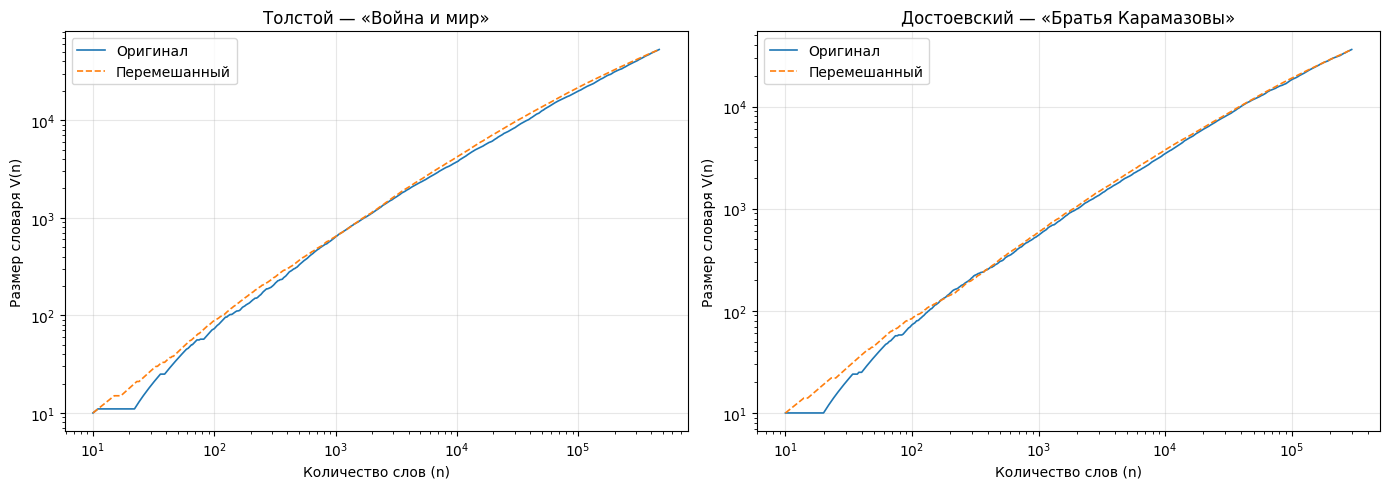

In [66]:
# График роста словаря
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Толстой
ax = axes[0]
ax.loglog(t_counts, t_sizes, linewidth=1.2, label="Оригинал")
ax.loglog(ts_counts, ts_sizes, '--', linewidth=1.2, label="Перемешанный")
ax.set_xlabel("Количество слов (n)")
ax.set_ylabel("Размер словаря V(n)")
ax.set_title("Толстой — «Война и мир»")
ax.legend()
ax.grid(True, alpha=0.3)

# Достоевский
ax = axes[1]
ax.loglog(d_counts, d_sizes, linewidth=1.2, label="Оригинал")
ax.loglog(ds_counts, ds_sizes, '--', linewidth=1.2, label="Перемешанный")
ax.set_xlabel("Количество слов (n)")
ax.set_ylabel("Размер словаря V(n)")
ax.set_title("Достоевский — «Братья Карамазовы»")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

На графиках видно: оригинал идёт «ступеньками» — при смене главы/темы словарь резко подскакивает (новые имена, лексика сцены), потом рост замедляется до следующей смены контекста. Перемешанный текст — плавная кривая без скачков, потому что все слова равномерно размазаны по тексту.

## 3. Характерные слова каждого автора

In [67]:
# Частотные словари
tolstoy_freq = Counter(tolstoy_words)
dostoevsky_freq = Counter(dostoevsky_words)

# Нормализованные частоты
t_total = len(tolstoy_words)
d_total = len(dostoevsky_words)

# Log-odds ratio: насколько слово характернее для одного автора
all_vocab = set(tolstoy_freq.keys()) | set(dostoevsky_freq.keys())

scores = {}
for word in all_vocab:
    tf = (tolstoy_freq.get(word, 0) + 1) / (t_total + len(all_vocab))
    df = (dostoevsky_freq.get(word, 0) + 1) / (d_total + len(all_vocab))
    scores[word] = np.log2(tf / df)

# Фильтруем: слово должно встречаться хотя бы 20 раз у автора
min_freq = 20

tolstoy_words_sorted = sorted(
    [(w, s, tolstoy_freq.get(w, 0)) for w, s in scores.items()
     if tolstoy_freq.get(w, 0) >= min_freq],
    key=lambda x: -x[1]
)

dostoevsky_words_sorted = sorted(
    [(w, s, dostoevsky_freq.get(w, 0)) for w, s in scores.items()
     if dostoevsky_freq.get(w, 0) >= min_freq],
    key=lambda x: x[1]
)

print("Топ-30 характерных слов Толстого:")
for i, (word, score, freq) in enumerate(tolstoy_words_sorted[:30], 1):
    print(f"  {i:2d}. {word:20s}  freq={freq:>5,}  log-odds={score:+.2f}")

print(f"\nТоп-30 характерных слов Достоевского:")
for i, (word, score, freq) in enumerate(dostoevsky_words_sorted[:30], 1):
    print(f"  {i:2d}. {word:20s}  freq={freq:>5,}  log-odds={-score:+.2f}")

Топ-30 характерных слов Толстого:
   1. чтò                   freq=1,666  log-odds=+10.16
   2. пьер                  freq=1,400  log-odds=+9.91
   3. княжна                freq=  570  log-odds=+8.62
   4. ростов                freq=  540  log-odds=+8.54
   5. пьера                 freq=  474  log-odds=+8.35
   6. граф                  freq=  474  log-odds=+8.35
   7. князь                 freq=1,355  log-odds=+8.28
   8. чтó                   freq=  319  log-odds=+7.78
   9. графиня               freq=  317  log-odds=+7.77
  10. кутузов               freq=  315  log-odds=+7.76
  11. соня                  freq=  283  log-odds=+7.61
  12. наташа                freq=  825  log-odds=+7.57
  13. войска                freq=  274  log-odds=+7.56
  14. денисов               freq=  272  log-odds=+7.55
  15. à                     freq=  270  log-odds=+7.54
  16. французов             freq=  248  log-odds=+7.42
  17. пьеру                 freq=  239  log-odds=+7.37
  18. князя                 fr

## 4. Выводы

**Закон Хипса.** Оба романа хорошо описываются степенным законом V(n) = k·nᵝ. У оригинальных текстов β выше (~0.818), чем у перемешанных (~0.798). У Достоевского разрыв Δβ больше (0.022 vs 0.017), что указывает на более резкую смену лексических пластов между главами.

**Сравнение авторов.** Достоевский лексически плотнее: при меньшем корпусе (298k vs 466k слов) его TTR выше (12.1% vs 11.4%). Толстой компенсирует это двуязычием — в «Войне и мире» значительная часть диалогов ведётся по-французски, что увеличивает общий словарь (53.0k vs 36.2k уникальных слов).

**Характерные слова.** Log-odds анализ выделяет для каждого автора имена персонажей и стилистические маркеры: у Толстого — Пьер, Наташа, Кутузов, французские слова (vous, à), архаизмы (чтò, ежели); у Достоевского — Алёша, Митя, Смердяков, экспрессивная лексика (воскликнул, вскричал, подлец, дескать). Это отражает разницу в стиле: Толстой — эпический нарратив с иноязычными вкраплениями, Достоевский — эмоциональный диалог.